<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Objective" data-toc-modified-id="Objective-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Objective</a></span><ul class="toc-item"><li><span><a href="#Drawbacks-of-k-means-Clustering" data-toc-modified-id="Drawbacks-of-k-means-Clustering-1.1"><span class="toc-item-num">1.1&nbsp;&nbsp;</span>Drawbacks of k-means Clustering</a></span></li><li><span><a href="#Gaussian-mixture-model-(GMM)" data-toc-modified-id="Gaussian-mixture-model-(GMM)-1.2"><span class="toc-item-num">1.2&nbsp;&nbsp;</span>Gaussian mixture model (GMM)</a></span></li><li><span><a href="#The-Gaussian-Distribution" data-toc-modified-id="The-Gaussian-Distribution-1.3"><span class="toc-item-num">1.3&nbsp;&nbsp;</span>The Gaussian Distribution</a></span></li><li><span><a href="#Gaussian-Mixture-Models" data-toc-modified-id="Gaussian-Mixture-Models-1.4"><span class="toc-item-num">1.4&nbsp;&nbsp;</span>Gaussian Mixture Models</a></span></li><li><span><a href="#Expectation-Maximization-(EM)-Algorithm" data-toc-modified-id="Expectation-Maximization-(EM)-Algorithm-1.5"><span class="toc-item-num">1.5&nbsp;&nbsp;</span>Expectation-Maximization (EM) Algorithm</a></span></li></ul></li><li><span><a href="#LAB-Assignment" data-toc-modified-id="LAB-Assignment-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>LAB Assignment</a></span><ul class="toc-item"><li><span><a href="#Exercise-(100-Points)" data-toc-modified-id="Exercise-(100-Points)-2.1"><span class="toc-item-num">2.1&nbsp;&nbsp;</span>Exercise (100 Points)</a></span><ul class="toc-item"><li><span><a href="#Import-some-libraries" data-toc-modified-id="Import-some-libraries-2.1.1"><span class="toc-item-num">2.1.1&nbsp;&nbsp;</span>Import some libraries</a></span></li><li><span><a href="#Load-Image" data-toc-modified-id="Load-Image-2.1.2"><span class="toc-item-num">2.1.2&nbsp;&nbsp;</span>Load Image</a></span></li><li><span><a href="#Initialize-means,-covariance-matrices-and-mixing-coefficients-of-GMM" data-toc-modified-id="Initialize-means,-covariance-matrices-and-mixing-coefficients-of-GMM-2.1.3"><span class="toc-item-num">2.1.3&nbsp;&nbsp;</span>Initialize means, covariance matrices and mixing coefficients of GMM</a></span></li><li><span><a href="#Implement-GMM-algorithm" data-toc-modified-id="Implement-GMM-algorithm-2.1.4"><span class="toc-item-num">2.1.4&nbsp;&nbsp;</span>Implement GMM algorithm</a></span><ul class="toc-item"><li><span><a href="#E-step" data-toc-modified-id="E-step-2.1.4.1"><span class="toc-item-num">2.1.4.1&nbsp;&nbsp;</span>E-step</a></span></li><li><span><a href="#M-step" data-toc-modified-id="M-step-2.1.4.2"><span class="toc-item-num">2.1.4.2&nbsp;&nbsp;</span>M-step</a></span></li></ul></li><li><span><a href="#Iteration" data-toc-modified-id="Iteration-2.1.5"><span class="toc-item-num">2.1.5&nbsp;&nbsp;</span>Iteration</a></span></li><li><span><a href="#Display" data-toc-modified-id="Display-2.1.6"><span class="toc-item-num">2.1.6&nbsp;&nbsp;</span>Display</a></span></li><li><span><a href="#sample-Result" data-toc-modified-id="sample-Result-2.1.7"><span class="toc-item-num">2.1.7&nbsp;&nbsp;</span>sample Result</a></span></li></ul></li></ul></li></ul></div>

# LAB12 tutorial for Machine Learning <br > Clustering with GMM
> The document description are designed by JIa Yanhong in 2022. Nov. 21th
------

## Objective

- Understand GMM clustering algorithm theory
- Implement the GMM clustering algorithm  from scratch in python
- Complete the LAB assignment.

------

### Drawbacks of k-means Clustering

The k-means clustering concept sounds pretty great, right? It’s simple to understand, relatively easy to implement, and can be applied in quite a number of use cases. But there are certain drawbacks and limitations that we need to be aware of. <font color=red>K-means often doesn't work when clusters are not round shaped</font>

First, KMeans doesn't put data points that are far away from each other into the same cluster, even when they obviously should be because they underly some obvious structure like points on a line, for example.


<div  align="center"> <img src="images/two_lines.png"  width=400 align=center /></div>



Second, KMeans performs poorly for complicated geometric shapes such as the moons and circles shown below.


<div  align="center"> 
<img src="images/noisy_moons_with_true_output.png"  width=400 align=center />
<img src="images/noisy_circles_with_true_output.png"  width=400 align=center />
</div>



In addition,k-means doesn't work when clusters are may overlap.
<div  align="center"> <img src="images/image-20221121170553059.png"  width=200 align=center /></div>


Hence, we need a different way to assign clusters to the data points.  So instead of using a distance-based model, we will now use a distribution-based model.  And that is where `Gaussian Mixture Models` come into this lab!

### Gaussian mixture model (GMM)

Gaussian Mixture Models (GMMs) assume that there are a certain number of Gaussian distributions, and each of these distributions represent a cluster.

**Gaussian Mixture Models are probabilistic models and use the soft clustering approach for distributing the points in different clusters.** 

 Let us take an example that will make it easier to understand.

Here, we have three clusters that are denoted by three colors – Blue, Green, and Cyan. Let’s take the data point highlighted in red. The probability of this point being a part of the blue cluster is 1, while the probability of it being a part of the green or cyan clusters is 0.


<div  align="center"> <img src="images/Screenshot-from-2019-10-21-12-52-06.png"  width=400 align=center /></div>
Now, consider another point – somewhere in between the blue and cyan (highlighted in the below figure). The probability that this point is a part of cluster green is 0, right? And the probability that this belongs to blue and cyan is 0.2 and 0.8 respectively.

<div  align="center"> <img src="images/Screenshot-from-2019-10-21-12-53-29.png"  width=400 align=center /></div>


Gaussian Mixture Models use the soft clustering technique for assigning data points to Gaussian distributions. 

### The Gaussian Distribution

In a one dimensional space, the **probability density function** of a Gaussian distribution is given by:



$$\mathcal{N}(X|\mu, \sigma)=\frac{1}{{\sigma \sqrt {2\pi } }}e^{-\frac{(x-\mu)^{2}}{2\sigma^{2}}}$$





where μ is the mean and $\sigma^{2}$ is the variance.

The below image has a few Gaussian distributions with a difference in mean (μ) and variance (σ2).


<div  align="center"> <img src="images/gaussians.png"  width=400 align=center /></div>

But this would only be true for a single variable. In the case of two variables, instead of a 2D bell-shaped curve, we will have a 3D bell curve as shown below:

<div  align="center"> <img src="images/gaussians-3d-166902260287820.png"  width=400 align=center /></div>

The probability density function would be given by:



$$\mathcal{N}(X|\mu, \Sigma)= \frac{1}{\sqrt{(2\pi)|\boldsymbol\Sigma|}} \exp\left(-\frac{1}{2}({X}-{\mu})^T{\boldsymbol\Sigma}^{-1}({X}-{\mu}) \right)    $$ 



where $X$ is the input vector, μ is the 2D mean vector, and Σ is the 2×2 covariance matrix. The covariance would now define the shape of this curve. We can generalize the same for d-dimensions.

Thus, this multivariate Gaussian model would have $X$ and $\mu$ as vectors of length d, and Σ would be a *d x d* covariance matrix.

### Gaussian Mixture Models

Suppose there are K clusters (For the sake of simplicity here it is assumed that the number of clusters is known and it is K). So $\mu$ and $ \Sigma$ are also estimated for each k. Had it been only one distribution, they would have been estimated by the **maximum-likelihood method**. But since there are K such clusters and the probability density is defined as a linear function of densities of all these K distributions, i.e.

$$p(\mathbf{x}) =\sum_{k=1}^K \pi_k \mathcal{N}(\mathbf{x}|\mu_k, \Sigma_k) 
\\
\left\{
\begin{aligned}
&\pi: \text{mixing coefficient}\\
&\pmb{\mu}: \text{means}\\
&\pmb{\Sigma}: \text{covariance matrix}
\end{aligned}
\right.
$$

where $\pi_k$   is the mixing coefficient for k-th distribution.

Assuming that data points are independent, for estimating the parameters by the maximum log-likelihood method, compute $\hspace{0.25 cm} {p( \mathbf{X}|\mu, \Sigma, \pi)}$.


$$ln\ p( \mathbf{X}|\mu, \Sigma, \pi) =\sum_{n=1}^N ln\ p(\mathbf{x}_n) =\sum_{n=1}^N ln {\sum_{k=1}^K \pi_k \mathcal{N}(\mathbf{x}_n | \mu_k, \Sigma_k)}  $$



Now define a random variable $\gamma_k(\mathbf{x}_n)$ , such that $\gamma_k(\mathbf{x}_n)  =p(k|\mathbf{x}_n)$.
From Bayes’ theorem, 


$$
\gamma_k(\mathbf{x}_n) =\frac{p(\mathbf{x}_n|k)p(k)}{\sum_{k=1}^K p(k)p(\mathbf{x}_n|k)} 
=\frac{p(\mathbf{x}_n|k)\pi_k}{\sum_{k=1}^K \pi_k p(\mathbf{x}_n|k)}
=\frac{\pi_k\mathcal{N}(\mathbf{x}_n | \mu_k, \Sigma_k)}{\sum_{k=1}^K \pi_k \mathcal{N}(\mathbf{x}_n | \mu_k, \Sigma_k)}$$

Now for the log-likelihood function to be maximum, its derivative of $p(x_n|\mu, \Sigma, \pi) $ with respect to $\mu$, $\Sigma $ and $\pi $ should be zero. So equating the derivative of $p(x_n|\mu, \Sigma, \pi) $ to zero and rearranging the terms, 


$$\mu_k=\frac{\sum_{n=1}^N \gamma_k(\mathbf{x}_n)\mathbf{x}_n}{\sum_{n=1}^N \gamma_k(\mathbf{x}_n)}$$



Similarly taking derivative with respect to $\Sigma $ and pi respectively, one can obtain the following expressions.

$$\Sigma_k=\frac{\sum_{n=1}^N \gamma_k(\mathbf{x}_n)(\mathbf{x}_n-\mu_k)(\mathbf{x}_n-\mu_k)^T}{\sum_{n=1}^N \gamma_k(\mathbf{x}_n)} \newline $$

And


$$\pi_k=\frac{1}{N} \sum_{n=1}^N \gamma_k(\mathbf{x}_n)$$



**Note:** $\sum_{n=1}^N\gamma_k(x_n) $ denotes the total number of sample points in the k-th cluster. Here it is assumed that there is a total N number of samples and each sample containing d features is denoted by $x_i $.
So it can be clearly seen that the parameters cannot be estimated in closed form. This is where the **Expectation-Maximization algorithm** is beneficial.

### Expectation-Maximization (EM) Algorithm

The Expectation-Maximization (EM) algorithm is an iterative way to find maximum-likelihood estimates for model parameters when the data is incomplete or has some missing data points or has some hidden variables. EM chooses some random values for the missing data points and estimates a new set of data. These new values are then recursively used to estimate a better first date, by filling up missing points, until the values get fixed. 
These are the two basic steps of the EM algorithm, namely **E Step or Expectation Step or Estimation Step** and **M Step or Maximization Step**.


- Estimation step (E step):
  - initialize $\mu_k   $, $\Sigma_k   $ and $\pi_k  $ by some random values, or by K means clustering results or by hierarchical clustering results.
  - Then for those given parameter values, estimate the value of the latent variables (i.e $\gamma_k(\mathbf{x}_n)   $)
  $$\gamma_k(\mathbf{x}_n) =\frac{\pi_k\mathcal{N}(\mathbf{x}_n | \mu_k, \Sigma_k)}{\sum_{k=1}^K \pi_k \mathcal{N}(\mathbf{x}_n | \mu_k, \Sigma_k)}$$
- Maximization Step(M step):
  - Update the value of the parameters( i.e. $\mu_k    $, $\Sigma_k     $ and $\pi_k    $) calculated using ML method.
  $$\mu_k=\frac{\sum_{n=1}^N \gamma_k(\mathbf{x}_n)\mathbf{x}_n}{\sum_{n=1}^N \gamma_k(\mathbf{x}_n)}$$
  $$\Sigma_k=\frac{\sum_{n=1}^N \gamma_k(\mathbf{x}_n)(\mathbf{x}_n-\mu_k)(\mathbf{x}_n-\mu_k)^T}{\sum_{n=1}^N \gamma_k(\mathbf{x}_n)} \newline $$
  $$\pi_k=\frac{1}{N} \sum_{n=1}^N \gamma_k(\mathbf{x}_n)$$



## LAB Assignment
Please finish the **Exercise**.

In this lab, our goal is to write a program to segment different objects using the **GMM and EM** algorithm. We also use <u>*k-means* clustering algorithm to initialize the parameters</u> of GMM. The following steps should be implemented to achieve such a goal:

1. Load image
2. Initialize parameters of GMM using K-means
3. Implement the EM algorithm for GMM
4. Display result

#### Import some libraries

In [1]:
# 依赖与常量
import numpy as np
from scipy.stats import multivariate_normal
from sklearn.cluster import KMeans
import tqdm
import cv2
from PIL import Image
import matplotlib.pyplot as plt

# 用于可视化的颜色表（RGB）
COLORS = [
    (255, 0, 0),   # red
    (0, 255, 0),   # green
    (0, 0, 255),   # blue
    (255, 255, 0), # yellow
    (255, 0, 255), # magenta
]

#### Load Image
What you should do is to implement Z-score normalization in `load()`:

In [2]:
def load(image_path):
    image = cv2.imread(image_path)
    if image is None:
        raise ValueError(f"Could not load image from path: {image_path}")
    h, w, c = image.shape
    # h: height of the image
    # w: width of the image
    # c: number of channels (e.g., 3 for RGB)

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB).astype(np.float64)
    pixels = image_rgb.reshape(-1, c)  # shape (N, c)
    # N: total number of pixels (h * w)
    # we flatten the image into a 2D array

    # TODO: please normalize image_pixl using Z-score
    
    _mean = np.mean(pixels, axis=0) # compute mean for each channel
    _std = np.std(pixels, axis=0) # compute std for each channel
    safe_std = np.where(_std <= 1e-12, 1.0, _std)
    image_norm = (pixels - _mean) / safe_std # normalize using Z-score
    
    return h, w, c, image_norm

#### Initialize means, covariance matrices and mixing coefficients of GMM
k-means is used to initialize means, covariance matrices and mixing coefficients of GMM

In [3]:
def kmeans(n_cluster, image_pixl):
    """
    使用 sklearn KMeans 对像素进行聚类并初始化 GMM 参数。
    参数:
      n_cluster: 聚类/组件数量
      image_pixl: 标准化后的像素矩阵，shape = (N, C)
    返回:
      initial_mus: (n_cluster, C) 聚类中心
      initial_priors: list 长度 n_cluster，每项为先验概率 pi_k
      initial_covs: list 长度 n_cluster，每项为 (C, C) 协方差矩阵
    说明:
      - 计算协方差时，样本格式为 (C, n_samples_in_cluster)，以适配 np.cov 接口
      - 若某一簇只有一个样本或样本过少，使用单位矩阵乘以小正则项
    """
    kmeans = KMeans(n_clusters=n_cluster, random_state=0)
    labels = kmeans.fit_predict(image_pixl)
    initial_mus = kmeans.cluster_centers_
    initial_priors, initial_covs = [], []
    N = len(labels)
    for i in range(n_cluster):
        # 选出属于第 i 类的样本（shape = (n_i, C)）
        cluster_pixels = image_pixl[labels == i]
        n_i = cluster_pixels.shape[0]
        if n_i <= 1:
            # 如果簇样本不足，使用全数据的协方差或单位矩阵来初始化，防止 singular
            cov = np.cov(image_pixl.T) if N > 1 else np.eye(image_pixl.shape[1])
        else:
            # np.cov 要求形状为 (C, n_i)
            cov = np.cov(cluster_pixels.T)
        # 添加小的正则化，防止后续矩阵奇异
        cov += np.eye(cov.shape[0]) * 1e-6
        prior = n_i / float(N)
        initial_covs.append(cov)
        initial_priors.append(prior)
    return initial_mus, initial_priors, initial_covs

#### Implement GMM algorithm
We use EM algorithm to refine GMM's parameters.

Although it may be not easy for some students to derive EM formula for GMM, GMM isn't very difficult to implement once you have the formula. Therefore, to help you understand GMM more, there are still some blanks for you to fill in.

<div  align="center"> <img src="images/EM-step.png"  /></div>

##### E-step
It is in `inference()`.

In the following code, `prob` is $\pi_k\mathcal{N}(\mathbf{x}_n|\pmb{\mu}_k,\pmb\Sigma_k)$, `gamma` is  $\gamma$. You need to implement log likelihood and $\gamma$.
```python
def inference(self, datas):
    probs = []
    for i in range(self.ncomp):
        mu, cov, prior = self.mus[i, :], self.covs[i, :, :], self.priors[i]
        prob = prior * multivariate_normal.pdf(datas, mean=mu, cov=cov, allow_singular=True)
        probs.append(np.expand_dims(prob, -1))
    preds = np.concatenate(probs, axis=1)
    
    # TODO: calc log likelihood
    log_likelihood = None

    # TODO: calc gamma
    gamma = None

    return gamma, log_likelihood
```

##### M-step
It is in `update()`

You need to implement mean $\mu$, covariance $\Sigma$ and mixing coefficient $\pi$ .
```python
def update(self, datas, gamma):
    new_mus, new_covs, new_priors = [], [], []
    soft_counts = np.sum(gamma, axis=0)
    for i in range(self.ncomp):
        # TODO: calc mu
        new_mu = None
        new_mus.append(new_mu)

        # TODO: calc cov
        new_cov = None
        new_covs.append(new_cov)

        # TODO: calc mixing coefficients
        new_prior = None
        new_priors.append(new_prior)

    self.mus = np.asarray(new_mus)
    self.covs = np.asarray(new_covs)
    self.priors = np.asarray(new_priors)
```

#### Iteration
Iteration part is as you see in `fit()`
``` python
def fit(self, data, iteration):
    prev_log_liklihood = None

    bar = tqdm.tqdm(total=iteration)
    for i in range(iteration):
        gamma, log_likelihood = self.inference(data)
        self.update(data, gamma)
        if prev_log_liklihood is not None and abs(log_likelihood - prev_log_liklihood) < 1e-10:
            break
        prev_log_likelihood = log_likelihood

        bar.update()
        bar.set_postfix({"log likelihood": log_likelihood})
```

In [4]:
class GMM:
    def __init__(self, ncomp, initial_mus, initial_covs, initial_priors):
        """
        ncomp: 组件数 K
        initial_mus: (K, D)
        initial_covs: list/array 长度 K, 每项 (D, D)
        initial_priors: list/array 长度 K
        """
        self.ncomp = ncomp
        self.mus = np.asarray(initial_mus)
        self.covs = np.asarray(initial_covs)
        self.priors = np.asarray(initial_priors)

    def inference(self, datas):
        """
        E-step:
          datas: shape (N, D)
        返回:
          gamma: shape (N, K) 每个样本属于每个组件的后验概率
          log_likelihood: 标量，整个数据集的对数似然和
        实现细节：
          - 计算每个组件的 p(k) * N(x | mu_k, cov_k)
          - 对每个样本求和以得到边缘概率，然后求 log 并累加
          - 规范化得到 gamma（对每一行除以该行的总概率）
          - 使用小常数 eps 提高数值稳定性
        """
        probs = []
        for i in range(self.ncomp):
            mu = self.mus[i]
            cov = self.covs[i]
            prior = self.priors[i]
            # multivariate_normal.pdf 在高维或协方差近似奇异时可能数值为0，allow_singular=True
            comp_prob = prior * multivariate_normal.pdf(datas, mean=mu, cov=cov, allow_singular=True)
            probs.append(np.expand_dims(comp_prob, -1))  # (N,1)
        # preds shape: (N, K)
        preds = np.concatenate(probs, axis=1)

        # 数值稳定处理：每行求和为样本的边缘概率 p(x_n)
        eps = 1e-12
        marginal = np.sum(preds, axis=1, keepdims=True)  # (N,1)
        # 防止出现 0 的情况
        marginal_safe = marginal + eps

        # log-likelihood: sum_n log p(x_n)
        log_likelihood = float(np.sum(np.log(marginal_safe)))

        # gamma: posterior responsibilities (N, K)
        gamma = preds / marginal_safe  # 广播除法

        return gamma, log_likelihood

    def update(self, datas, gamma):
        """
        M-step:
          datas: (N, D)
          gamma: (N, K)
        更新 self.mus, self.covs, self.priors
        实现细节：
          - soft_counts[k] = sum_n gamma[n,k]
          - mu_k = (sum_n gamma[n,k] * x_n) / soft_counts[k]
          - cov_k = (sum_n gamma[n,k] * (x_n - mu_k)(x_n - mu_k)^T) / soft_counts[k]
          - prior_k = soft_counts[k] / N
          - 对协方差矩阵加上小的对角正则化以防奇异
        """
        N, D = datas.shape
        soft_counts = np.sum(gamma, axis=0)  # shape (K,)
        new_mus = []
        new_covs = []
        new_priors = []

        for k in range(self.ncomp):
            nk = soft_counts[k]
            if nk <= 1e-12:
                # 如果某组件几乎没有被激活，保留旧参数或使用全局值
                new_mu = self.mus[k]
                new_cov = self.covs[k]
                new_prior = 1e-12
            else:
                # 计算新的均值（加权平均）
                # gamma[:, k] shape (N,), 扩展为 (N,1) 以便广播
                weight = gamma[:, k:k+1]  # (N,1)
                new_mu = (weight * datas).sum(axis=0) / nk  # (D,)

                # 计算加权协方差
                diff = datas - new_mu  # (N, D)
                # (D, D) = (diff * weight).T @ diff / nk
                weighted_diff = diff * weight  # (N, D)
                new_cov = (weighted_diff.T @ diff) / nk  # (D, D)

                # 对协方差做小正则化以防奇异
                new_cov += np.eye(D) * 1e-6

                # mixing coefficient
                new_prior = nk / float(N)

            new_mus.append(new_mu)
            new_covs.append(new_cov)
            new_priors.append(new_prior)

        # 更新参数
        self.mus = np.asarray(new_mus)
        self.covs = np.asarray(new_covs)
        # 正则化 priors 使其和为 1（避免数值漂移）
        priors_arr = np.asarray(new_priors)
        priors_sum = priors_arr.sum()
        if priors_sum <= 0:
            # fallback 均匀分布
            self.priors = np.ones_like(priors_arr) / len(priors_arr)
        else:
            self.priors = priors_arr / priors_sum

    def fit(self, data, iteration):
        """
        迭代执行 EM：
          data: (N, D)
          iteration: 最大迭代次数
        注意：
          - 使用 prev_log_likelihood 进行收敛判断（修正原代码拼写错误）
          - 在每次迭代后打印/更新进度条
        """
        prev_log_likelihood = None

        bar = tqdm.tqdm(total=iteration)
        for i in range(iteration):
            gamma, log_likelihood = self.inference(data)
            self.update(data, gamma)

            # 收敛判断
            if prev_log_likelihood is not None and abs(log_likelihood - prev_log_likelihood) < 1e-10:
                bar.set_postfix({"log likelihood": log_likelihood})
                bar.update()
                break

            prev_log_likelihood = log_likelihood
            bar.update()
            bar.set_postfix({"log likelihood": log_likelihood})
        bar.close()

#### Display
We use `matplotlib` to display what we segment, you can check the code in `visualize()`

In [5]:
def visualize(gmm, image, ncomp, ih, iw):
    """
    可视化分割结果：
      - gmm.inference(image) 返回 beliefs shape (N, K)
      - 将其 reshape 回 (ih, iw, K)，对每个像素取 argmax 得到硬分配
      - 使用 COLORS 映射到 RGB 显示
    参数:
      image: 标准化后的像素矩阵 (N, D)
      ih, iw: 原始图像高度与宽度
    """
    beliefs, log_likelihood = gmm.inference(image)
    # beliefs shape (N, K) -> reshape (ih, iw, K)
    map_beliefs = np.reshape(beliefs, (ih, iw, ncomp))
    segmented_map = np.zeros((ih, iw, 3))
    for i in range(ih):
        for j in range(iw):
            hard_belief = np.argmax(map_beliefs[i, j, :])
            segmented_map[i, j, :] = np.asarray(COLORS[hard_belief]) / 255.0
    plt.figure(figsize=(8, 6))
    plt.imshow(segmented_map)
    plt.axis('off')
    plt.show()

/opt/homebrew/Caskroom/miniconda/base/envs/mldl/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


GMM begins...


 15%|█▌        | 75/500 [00:02<00:15, 27.14it/s, log likelihood=2.2e+5] 


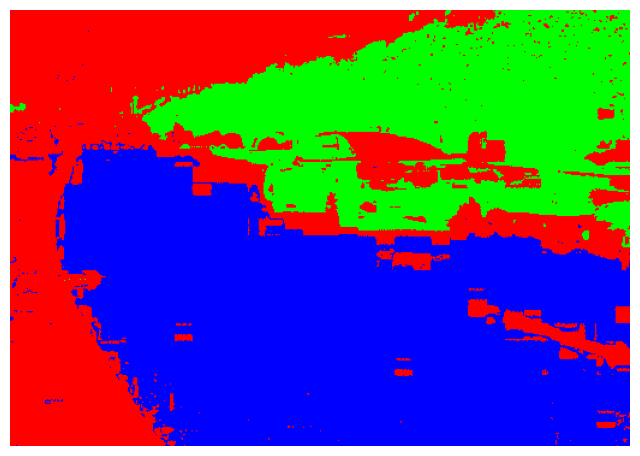

Finish!


In [6]:
# 示例主流程（将其放在 notebook 的执行单元中）
image_path = "data/original/sample.png"  # 根据你的路径修改
ih, iw, ic, image_norm = load(image_path)  # image_norm: (N, C)
ncomp = 3
iteration = 500

# 初始化（输入要求 image_norm 为 (N, C)）
initial_mus, initial_priors, initial_covs = kmeans(ncomp, image_norm)

# 创建并训练 GMM
print("GMM begins...")
gmm = GMM(ncomp, initial_mus, initial_covs, initial_priors)
gmm.fit(image_norm, iteration)

# 可视化分割结果
visualize(gmm, image_norm, ncomp, ih, iw)
print("Finish!")

#### sample Result
<img src="images/image-20220804223008133.png" alt="image-20220804223008133" style="zoom:67%;" />
<img src="images/image-20220804222915979.png" alt="image-20220804222915979" style="zoom: 67%;" />